/var/folders/ql/2lytyfbj10g0gs16jmbrkf3w0000gn/T/ipykernel_99062/3454986435.py:21: UserWarning: Glyph 27169 (\N{CJK UNIFIED IDEOGRAPH-6A21}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ql/2lytyfbj10g0gs16jmbrkf3w0000gn/T/ipykernel_99062/3454986435.py:21: UserWarning: Glyph 22411 (\N{CJK UNIFIED IDEOGRAPH-578B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ql/2lytyfbj10g0gs16jmbrkf3w0000gn/T/ipykernel_99062/3454986435.py:21: UserWarning: Glyph 35268 (\N{CJK UNIFIED IDEOGRAPH-89C4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ql/2lytyfbj10g0gs16jmbrkf3w0000gn/T/ipykernel_99062/3454986435.py:21: UserWarning: Glyph 21534 (\N{CJK UNIFIED IDEOGRAPH-541E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ql/2lytyfbj10g0gs16jmbrkf3w0000gn/T/ipykernel_99062/3454986435.py:21: UserWarning: Glyph 21520 (\N{CJK UNIFIED IDEOGRAPH-5410}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ql/2lyt

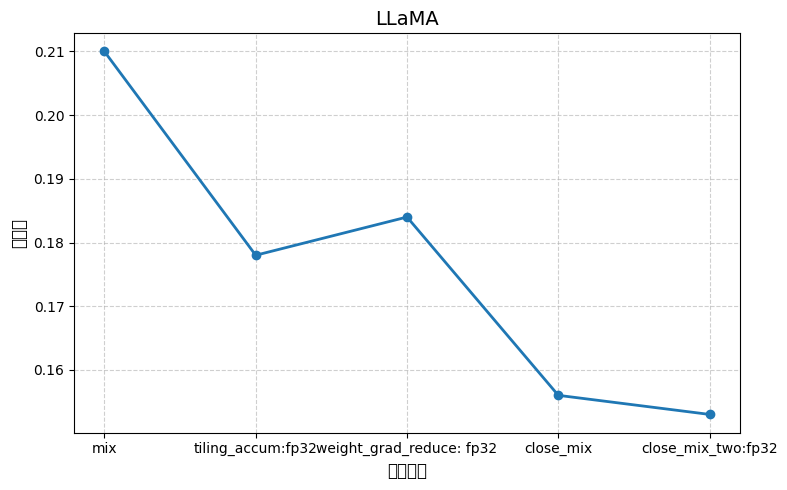

In [7]:
import matplotlib.pyplot as plt

# 模型规模（x轴）
model_sizes = ['mix', 'tiling_accum:fp32', 'weight_grad_reduce: fp32', 'close_mix',"close_mix_two:fp32"]
# 吞吐量（y轴），单位为 tokens/s
throughputs = [0.21, 0.178,  0.184, 0.156,0.153]

# 创建折线图
plt.figure(figsize=(8, 5))
plt.plot(model_sizes, throughputs, marker='o', linestyle='-', linewidth=2)

# 添加标题和坐标轴标签
plt.title('LLaMA' , fontsize=14)
plt.xlabel('模型规模', fontsize=12)
plt.ylabel('吞吐量', fontsize=12)

# 显示网格线
plt.grid(True, linestyle='--', alpha=0.6)

# 显示图形
plt.tight_layout()
plt.show()

/var/folders/ql/2lytyfbj10g0gs16jmbrkf3w0000gn/T/ipykernel_91896/1117772942.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_o0['OptLevel'] = 'O0'
/var/folders/ql/2lytyfbj10g0gs16jmbrkf3w0000gn/T/ipykernel_91896/1117772942.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_o3['OptLevel'] = 'O3'
/var/folders/ql/2lytyfbj10g0gs16jmbrkf3w0000gn/T/ipykernel_91896/1117772942.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,co

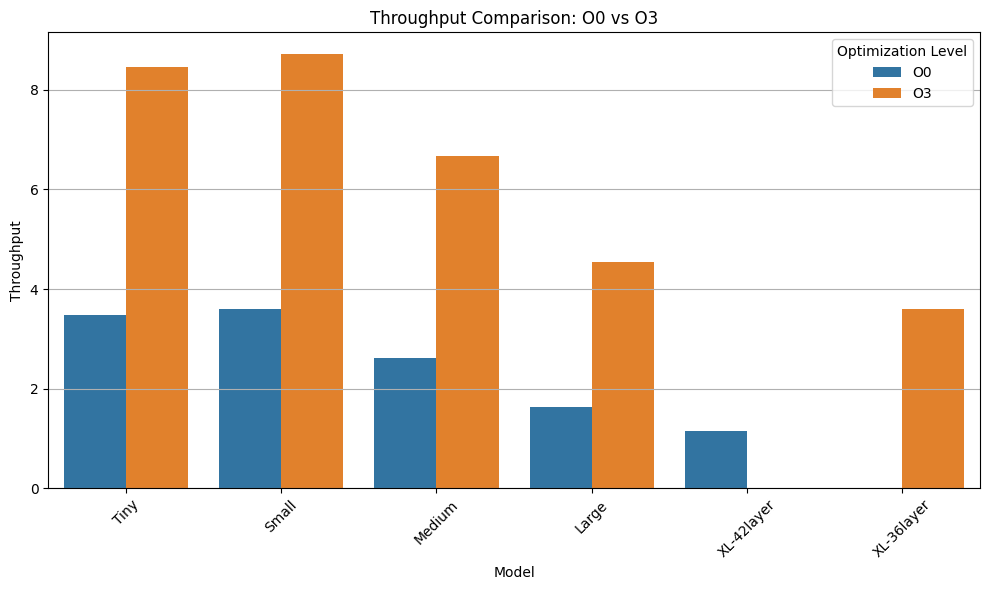

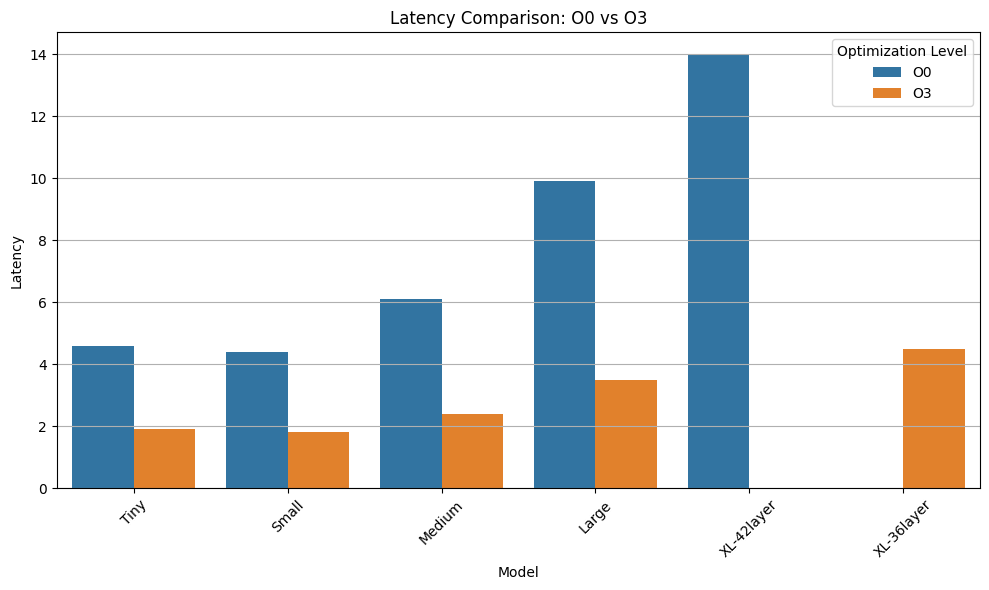

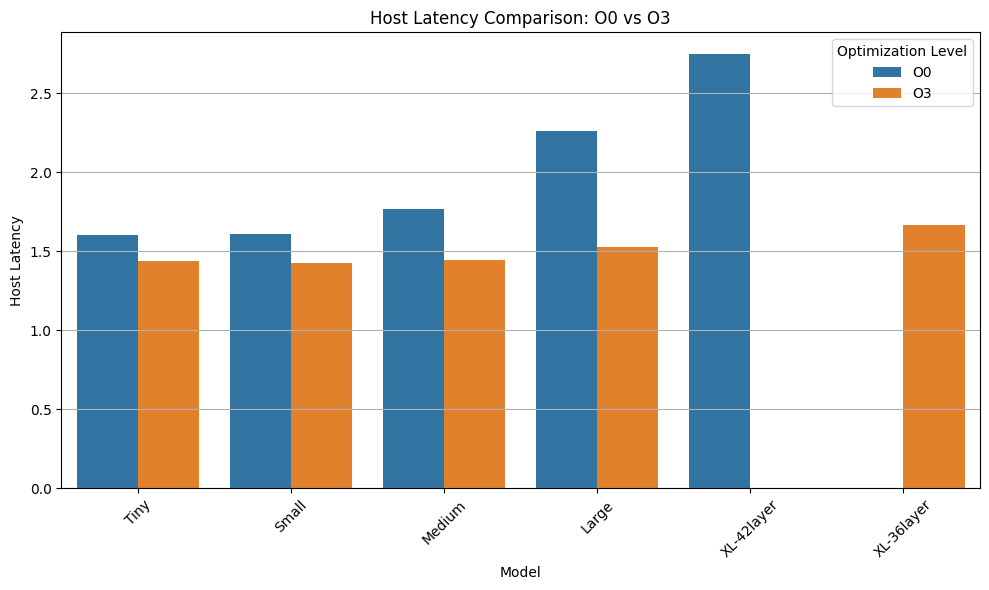

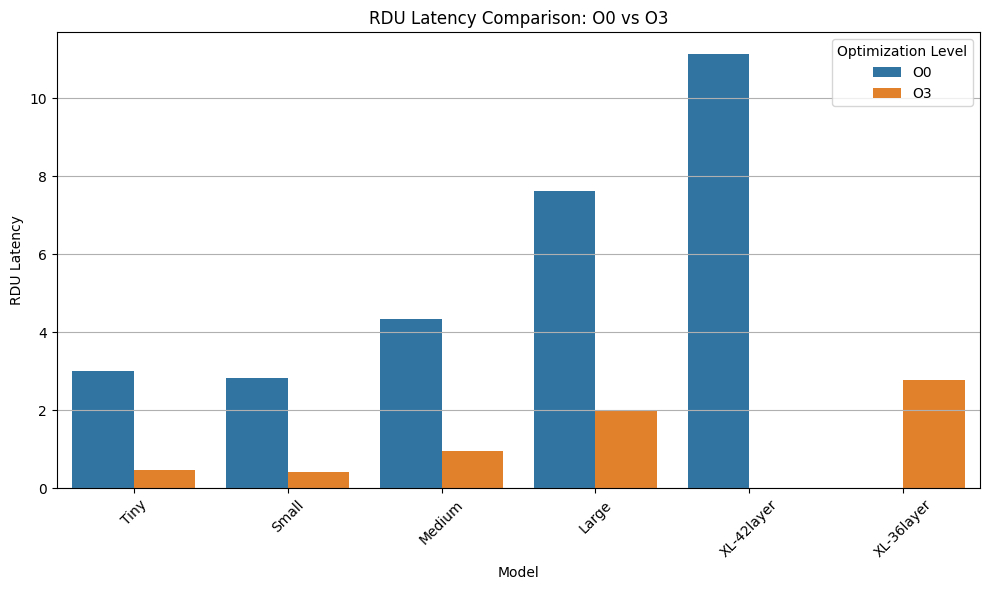

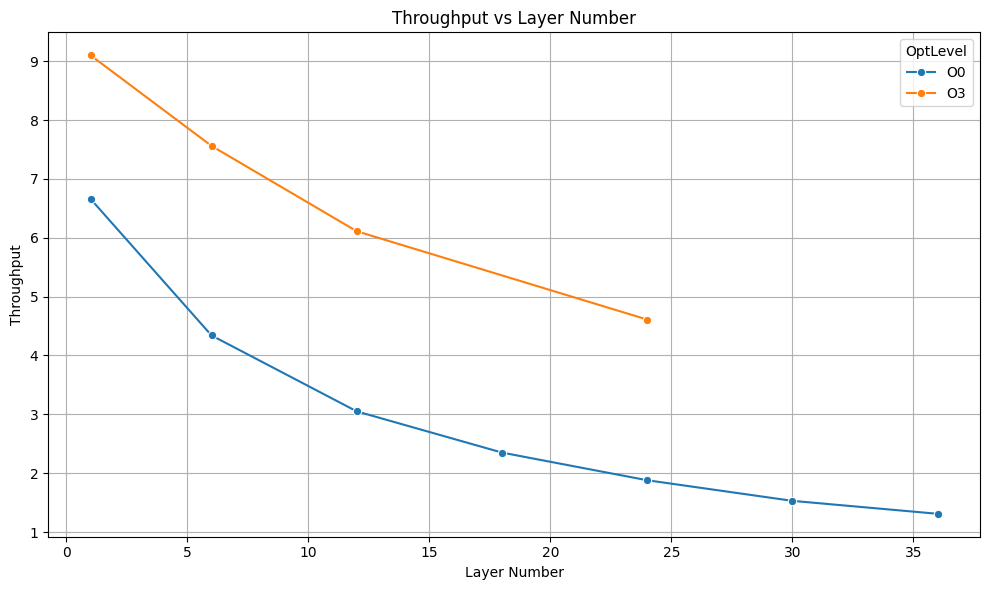

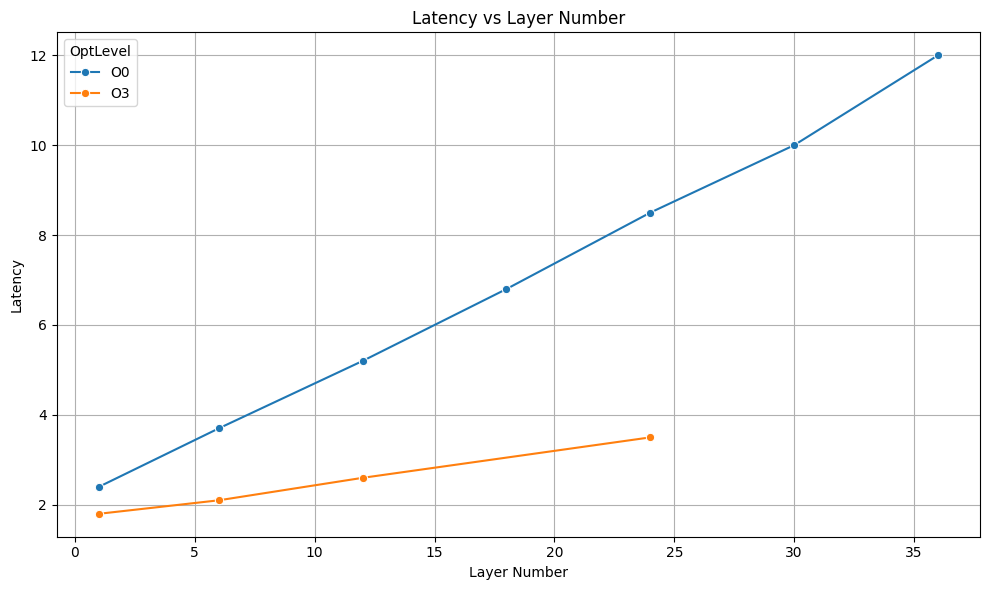

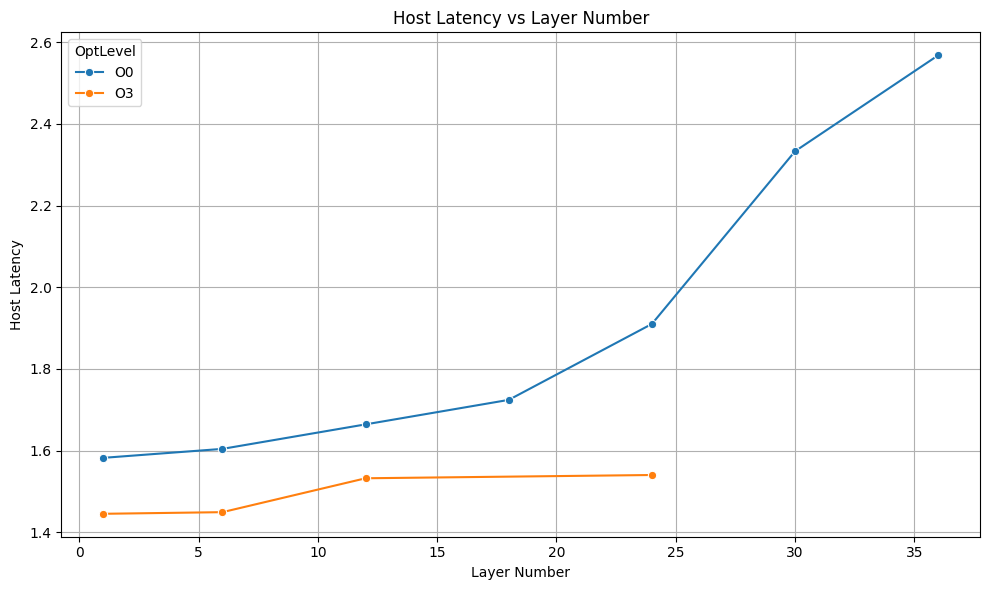

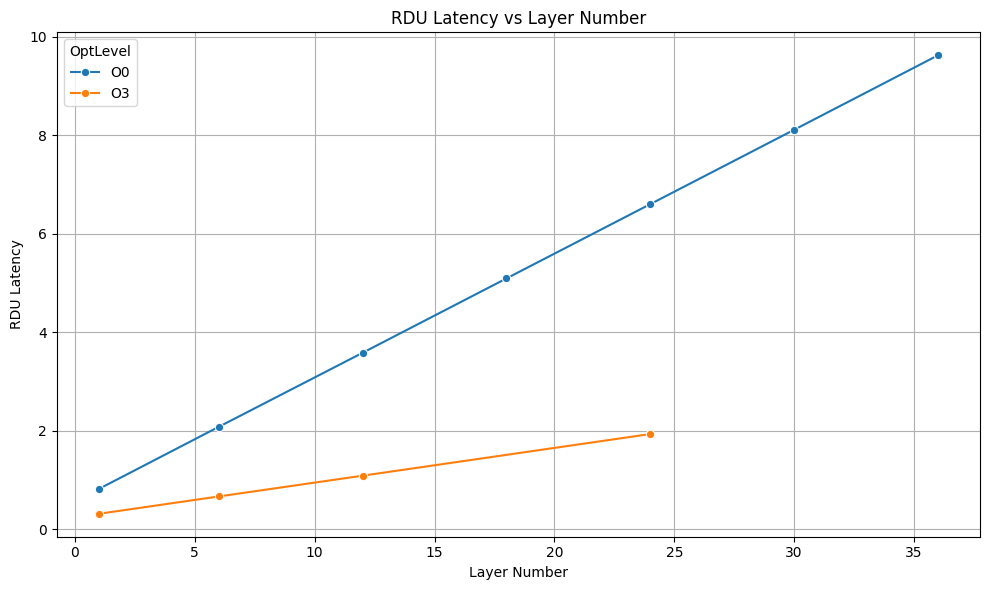

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 读取数据
file_path = '/Users/huziyu/Downloads/sambanova_results.csv'
df = pd.read_csv(file_path)
df.columns = [c.strip() for c in df.columns]

# 分组：O0和O3
o3_start_idx = df[df['O0'] == 'O3'].index.min()
df_o0 = df.iloc[:o3_start_idx]
df_o3 = df.iloc[o3_start_idx+1:]

# 添加标记：是O0还是O3
df_o0['OptLevel'] = 'O0'
df_o3['OptLevel'] = 'O3'

# 合并
df_all = pd.concat([df_o0, df_o3], ignore_index=True)

# 清理模型名：从embd size和layer number猜测

def infer_model_name(row):
    if pd.notna(row['Embd size']) and pd.notna(row['Layer number']):
        embd = row['Embd size']
        layer = row['Layer number']
        if embd == 480 and layer == 12:
            return 'Tiny'
        elif embd == 768 and layer == 12:
            return 'Small'
        elif embd == 1024 and layer == 24:
            return 'Medium'
        elif embd == 1280 and layer == 36:
            return 'Large'
        elif embd == 1600 and layer == 42:
            return 'XL-42layer'
        elif embd == 1600 and layer == 36:
            return 'XL-36layer'
    return row['O0']

# 填补模型名
for df_part in [df_o0, df_o3]:
    df_part['Model'] = df_part.apply(infer_model_name, axis=1)

# 再合并
df_all = pd.concat([df_o0, df_o3], ignore_index=True)

# 由于初始文件有两列空值，删除
cols_to_use = ['Model', 'Layer number', 'OptLevel', 'Throughput', 'Latency', 'Host Latency', 'RDU Latency']
df_all = df_all[cols_to_use]

### --- Part 1: O0 vs O3 比较 ---

models = df_all['Model'].unique()
metrics = ['Throughput', 'Latency', 'Host Latency', 'RDU Latency']

for metric in metrics:
    plt.figure(figsize=(10,6))
    sns.barplot(data=df_all[df_all['Model'].isin(['Tiny','Small','Medium','Large','XL-42layer','XL-36layer'])],
                x='Model', y=metric, hue='OptLevel')
    plt.title(f'{metric} Comparison: O0 vs O3')
    plt.ylabel(metric)
    plt.xlabel('Model')
    plt.legend(title='Optimization Level')
    plt.xticks(rotation=45)
    plt.grid(True, axis='y')
    plt.tight_layout()
    plt.show()

### --- Part 2: 同模型不同Layer数对比 ---

# 选择属于O0的，后续可以做O3的
layer_models = ['1layer','6layer','12layer','18layer','24layer','30layer','36layer']

for metric in metrics:
    plt.figure(figsize=(10,6))
    sns.lineplot(data=df_all[df_all['Model'].isin(layer_models)],
                 x='Layer number', y=metric, hue='OptLevel', marker='o')
    plt.title(f'{metric} vs Layer Number')
    plt.ylabel(metric)
    plt.xlabel('Layer Number')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
